In [25]:
%pip -q install scikit-learn joblib pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pandas numpy matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 12.8 MB/s  0:00:00m0:00:0100:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [seaborn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Model Comparison Results:
                 Model  Accuracy  F1-Score
1        Random Forest  0.829418  0.818843
2        Decision Tree  0.781320  0.779509
3    Gradient Boosting  0.746085  0.720122
0  Logistic Regression  0.665548  0.625926

Detailed Classification Report for Random Forest (Best Model):
              precision    recall  f1-score   support

        calm       0.90      0.44      0.59       286
     neutral       0.79      0.91      0.85       676
    stressed       0.85      0.90      0.87       826

    accuracy                           0.83      1788
   macro avg       0.85      0.75      0.77      1788
weighted avg       0.84      0.83      0.82      1788



/var/folders/l6/18hkcypx601_spb15xn_ptr40000gn/T/ipykernel_57893/3687555718.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1-Score', y='Model', data=results_df, palette='viridis')


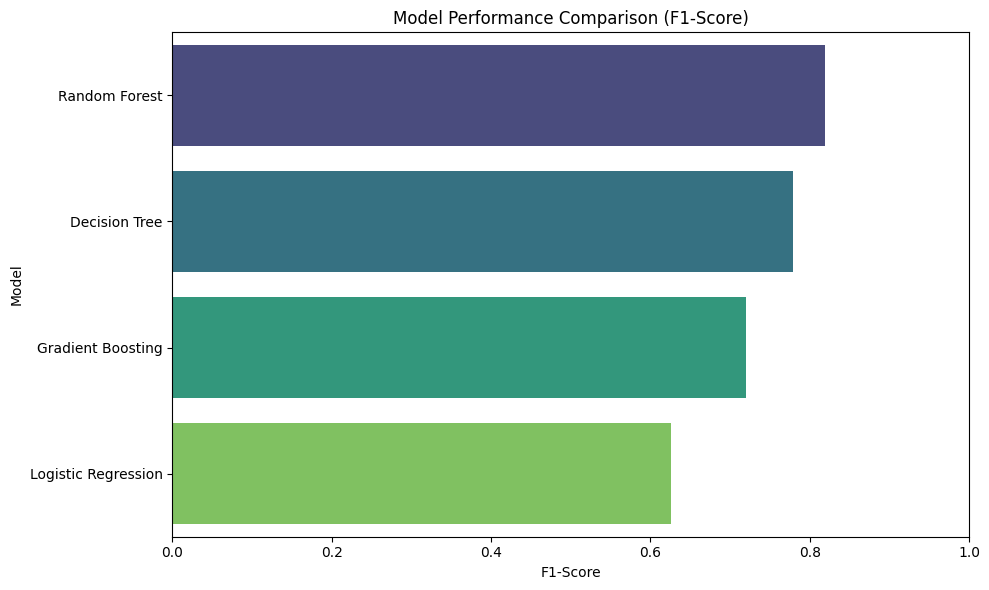

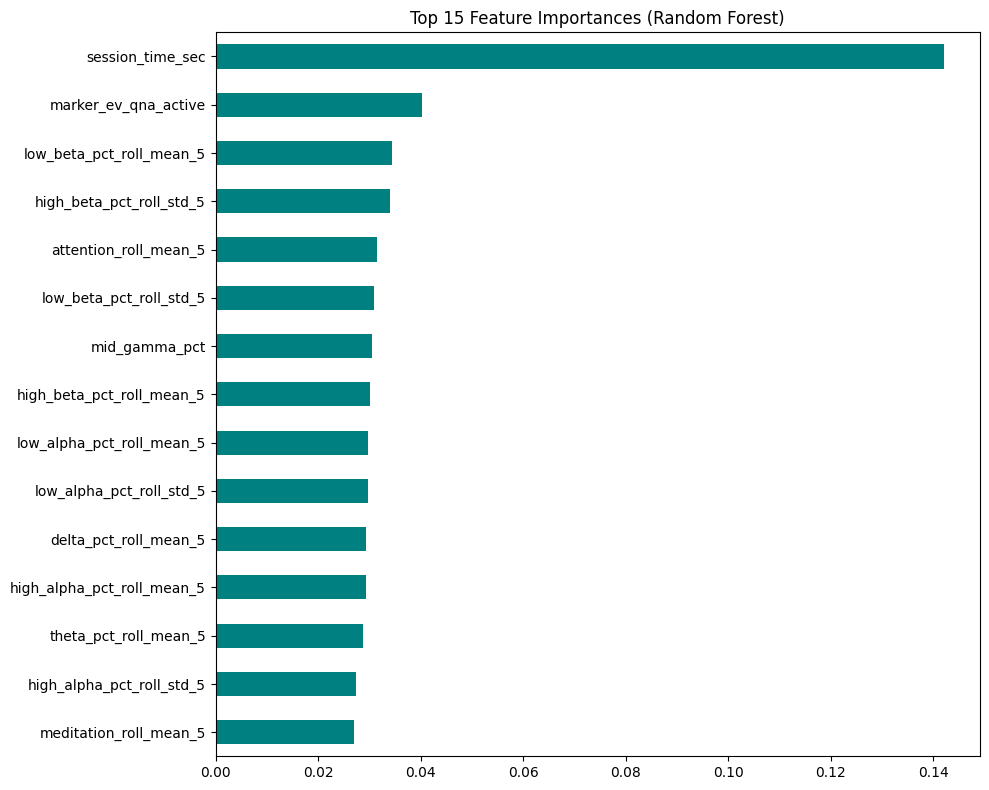

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the featured dataset
df = pd.read_csv('featured_mindtune.csv')
df = df.drop_duplicates(subset=['session_id', 'timestamp_ms'], keep='first')

# Define features and target
# Exclude identifiers and the string label
drop_cols = ['session_id', 'participant_id', 'timestamp_ms', 'label_3class', 'label_encoded']
X = df.drop(columns=drop_cols)
y = df['label_encoded']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, solver="lbfgs", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    # Use scaled data for LogReg, raw data for others
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    trained_models[name] = model
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)

print("Model Comparison Results:")
print(results_df)

# Plotting the results
plt.figure(figsize=(10, 6))
sns.barplot(x='F1-Score', y='Model', data=results_df, palette='viridis')
plt.title('Model Performance Comparison (F1-Score)')
plt.xlim(0, 1.0)
plt.tight_layout()
plt.savefig('model_comparison.png')

# Detailed report for the best model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

if best_model_name == "Logistic Regression":
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

print(f"\nDetailed Classification Report for {best_model_name} (Best Model):")
print(classification_report(y_test, y_pred_best, target_names=['calm', 'neutral', 'stressed']))

# Feature Importance for the best tree-based model (if applicable)
if best_model_name in ["Random Forest", "Gradient Boosting", "Decision Tree"]:
    importances = best_model.feature_importances_
    feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(10, 8))
    feat_importances.sort_values().plot(kind='barh', color='teal')
    plt.title(f'Top 15 Feature Importances ({best_model_name})')
    plt.tight_layout()
    plt.savefig('feature_importance.png')

/opt/homebrew/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Error training QDA: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.
Extended Model Comparison Results:
                   Model  Accuracy  F1-Score
1            Extra Trees  0.855145  0.849796
0          Random Forest  0.829418  0.818843
2          Decision Tree  0.781320  0.779509
5       MLP (Neural Net)  0.768456  0.766616
3    K-Nearest Neighbors  0.750000  0.749919
4      Gradient Boosting  0.746085  0.720122
7    Logistic Regression  0.665548  0.625926
9                    LDA  0.658277  0.615333
6             Linear SVC  0.663311  0.612390
12        SGD Classifier  0.656600  0.610642
8       Ridge Classifier  0.659955  0.607452
10              AdaBoost  0.653244  0.597996
11  Gaussian Naive Bayes  0.485459  0.472206

Top Performer: Extra Trees
              precision    recall  f1-score   support

        calm       0.92      0.56      0.70       286
     neutral       0.81      0.92      0.86       676
    stresse

/var/folders/l6/18hkcypx601_spb15xn_ptr40000gn/T/ipykernel_57893/916875921.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1-Score', y='Model', data=results_df, palette='magma')


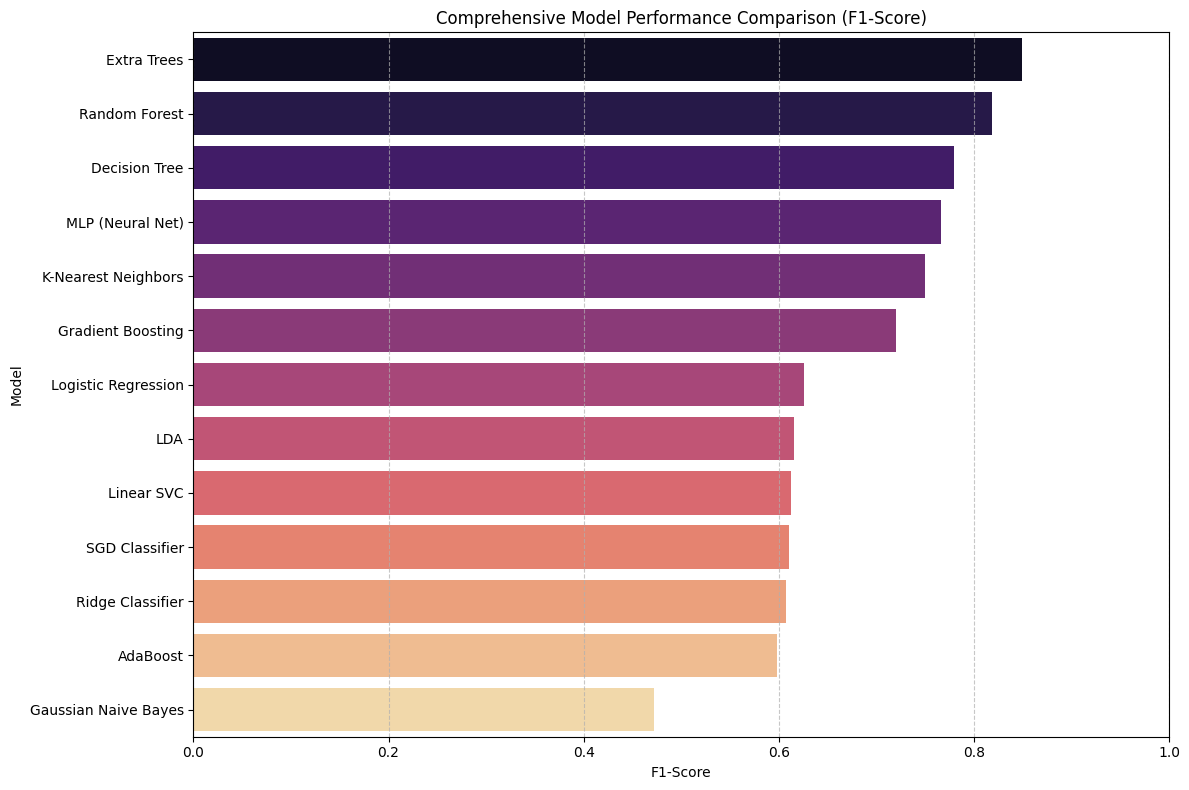

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Importing more models
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Load the featured dataset
df = pd.read_csv('featured_mindtune.csv')
df = df.drop_duplicates(subset=['session_id', 'timestamp_ms'], keep='first')
# Define features and target
drop_cols = ['session_id', 'participant_id', 'timestamp_ms', 'label_3class', 'label_encoded']
X = df.drop(columns=drop_cols)
y = df['label_encoded']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling features (Required for many models like KNN, SVM, MLP, LogReg)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define an extensive list of models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "MLP (Neural Net)": MLPClassifier(max_iter=500, random_state=42),
    "Linear SVC": LinearSVC(max_iter=2000, random_state=42, dual=False),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Ridge Classifier": RidgeClassifier(random_state=42),
    "LDA": LinearDiscriminantAnalysis(),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "SGD Classifier": SGDClassifier(random_state=42)
}

results = []
trained_models = {}

# Iterate through models
for name, model in models.items():
    # Use scaled data for models sensitive to scale
    needs_scaling = ["K-Nearest Neighbors", "Linear SVC", "Logistic Regression", 
                     "Ridge Classifier", "MLP (Neural Net)", "SGD Classifier", "LDA", "QDA"]
    
    X_train_to_use = X_train_scaled if name in needs_scaling else X_train
    X_test_to_use = X_test_scaled if name in needs_scaling else X_test
    
    try:
        model.fit(X_train_to_use, y_train)
        y_pred = model.predict(X_test_to_use)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})
        trained_models[name] = model
    except Exception as e:
        print(f"Error training {name}: {e}")

# Compile and sort results
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
results_df.to_csv('extended_model_comparison.csv', index=False)

print("Extended Model Comparison Results:")
print(results_df)

# Plotting the results
plt.figure(figsize=(12, 8))
sns.barplot(x='F1-Score', y='Model', data=results_df, palette='magma')
plt.title('Comprehensive Model Performance Comparison (F1-Score)')
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('extended_comparison_plot.png')

# Detailed report for the top model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
needs_scaling = ["K-Nearest Neighbors", "Linear SVC", "Logistic Regression", "Ridge Classifier", "MLP (Neural Net)", "SGD Classifier", "LDA", "QDA"]
X_test_best = X_test_scaled if best_model_name in needs_scaling else X_test
y_pred_best = best_model.predict(X_test_best)

print(f"\nTop Performer: {best_model_name}")
print(classification_report(y_test, y_pred_best, target_names=['calm', 'neutral', 'stressed']))

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Plotting is optional (comment out if you don't have these installed)
import matplotlib.pyplot as plt
import seaborn as sns

# Importing more models
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Optional boosters (install if missing):
#   python3 -m pip install xgboost lightgbm
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBMClassifier = None

# Load the featured dataset
df = pd.read_csv("featured_mindtune.csv")
df = df.drop_duplicates(subset=['session_id', 'timestamp_ms'], keep='first')


# Define features and target
drop_cols = ["session_id", "participant_id", "timestamp_ms", "label_3class", "label_encoded"]
X = df.drop(columns=drop_cols)
y = df["label_encoded"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling features (Required for many models like KNN, SVM, MLP, LogReg)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=600, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=25),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "MLP (Neural Net)": MLPClassifier(max_iter=800, random_state=42),
    "Linear SVC": LinearSVC(max_iter=8000, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    "Ridge Classifier": RidgeClassifier(random_state=42),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "Gaussian Naive Bayes": GaussianNB(),
    "SGD Classifier": SGDClassifier(random_state=42),
}

if XGBClassifier is not None:
    models["XGBoost"] = XGBClassifier(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )

if LGBMClassifier is not None:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
    )

results = []
trained_models = {}

needs_scaling = {
    "K-Nearest Neighbors",
    "Linear SVC",
    "Logistic Regression",
    "Ridge Classifier",
    "MLP (Neural Net)",
    "SGD Classifier",
    "LDA",
    "QDA",
}

for name, model in models.items():
    X_train_to_use = X_train_scaled if name in needs_scaling else X_train
    X_test_to_use = X_test_scaled if name in needs_scaling else X_test

    try:
        model.fit(X_train_to_use, y_train)
        y_pred = model.predict(X_test_to_use)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted")
        results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})
        trained_models[name] = model
    except Exception as e:
        print(f"Error training {name}: {e}")

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
X_test_best = X_test_scaled if best_model_name in needs_scaling else X_test
y_pred_best = best_model.predict(X_test_best)

print(f"\nTop Performer: {best_model_name}")
print(classification_report(y_test, y_pred_best, target_names=["calm", "neutral", "stressed"]))

Error training QDA: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.
                   Model  Accuracy  F1-Score
1            Extra Trees  0.857942  0.852164
0          Random Forest  0.831655  0.820301
2          Decision Tree  0.781320  0.779509
6       MLP (Neural Net)  0.777405  0.777440
4      Gradient Boosting  0.766219  0.749308
3    K-Nearest Neighbors  0.707494  0.696789
8    Logistic Regression  0.665548  0.625926
10                   LDA  0.658277  0.615333
7             Linear SVC  0.663311  0.612390
12        SGD Classifier  0.656600  0.610642
5               AdaBoost  0.657718  0.607961
9       Ridge Classifier  0.659955  0.607452
11  Gaussian Naive Bayes  0.485459  0.472206

Top Performer: Extra Trees
              precision    recall  f1-score   support

        calm       0.94      0.55      0.70       286
     neutral       0.81      0.93      0.87       676
    stressed       0.88      0.91      0.90   

In [11]:
import joblib
joblib.dump(best_model, 'extra_trees_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']